# Hawaii Fires

### Prepare Workspace

In [1]:
# Load system libraries
import os

# Load progress bar
from tqdm import tqdm

# Load data manipulation libraries
import numpy as np
import pandas as pd
import itertools

# Load spatial data libraries
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling
from shapely.geometry import Point, Polygon, box

# Load statistical libraries
from scipy import stats
from scipy.stats import mode
import statsmodels.api as sm
from scipy.stats import chi2_contingency

# Load data visualisation libraries
import matplotlib.pyplot as plt

# Load preprocessing libraries
from data.teleconnections import oni
from data.teleconnections import sst

### Clean Data

##### *Fire*

In [9]:
# Read fire data
df_fire = gpd.read_file('data/fires/fires_1999_2022.shp')

# Standardise data types
df_fire['Year'] = df_fire['Year'].astype(int)
df_fire['Month'] = df_fire['Month'].astype(int)

# Get counts of wildfires
df_fire_counts = df_fire.groupby(['Year', 'Month']).size().reset_index()
df_fire_counts.rename({0: 'count'}, axis=1, inplace=True)

# Get area of wildfires
df_fire_area = df_fire[['Year', 'Month', 'area_ha']].groupby(['Year', 'Month']).sum().reset_index()

# Fix column names
df_fire.columns = [col.lower() for col in df_fire.columns]

# Create column for year-month
df_fire['year_month'] = df_fire['year'].astype(str) + '-' + df_fire['month'].astype(str).str.zfill(2)

# Select columns of interest
df_fire = df_fire[['year_month', 'area_ha', 'geometry']]

In [12]:
df_fire

,year_month,area_ha,geometry
0,1999-04,3944.279517,"POLYGON ((-155.67671 19.77519, -155.67613 19.7..."
1,1999-07,173.792210,"POLYGON ((-155.66504 19.88082, -155.66623 19.8..."
2,1999-07,240.707400,"POLYGON ((-155.67689 19.92371, -155.67695 19.9..."
3,1999-09,3.533770,"POLYGON ((-155.30898 19.26119, -155.30923 19.2..."
4,2000-07,0.687402,"POLYGON ((-155.65715 19.86799, -155.65764 19.8..."
...,...,...,...
366,2022-04,16.839916,"POLYGON ((-155.70291 19.97372, -155.70279 19.9..."
367,2022-11,673.105602,"MULTIPOLYGON (((-156.66311 20.88150, -156.6617..."
368,2022-08,6092.480733,"POLYGON ((-155.77411 19.77062, -155.77196 19.7..."
369,2022-08,133.902936,"POLYGON ((-155.63376 18.98239, -155.63372 18.9..."


##### *Teleconnections*

In [3]:
# Process teleconnection data
df_oni = oni.process_oni()
df_sst = sst.process_sst()

2024-08-04 17:29:06.768 | INFO     | teleconnections.oni:download_oni:22 - Downloading ONI data...
2024-08-04 17:29:07.246 | INFO     | teleconnections.oni:download_oni:25 - Output file path is /Users/jessicarapson/Desktop/Projects/Data/2-In Progress/Hawaii Fire/teleconnections/oni.txt
2024-08-04 17:29:07.248 | INFO     | teleconnections.oni:download_oni:27 - File exists. Skipping.
2024-08-04 17:29:07.249 | SUCCESS  | teleconnections.oni:download_oni:33 - ONI download complete.
2024-08-04 17:29:07.268 | INFO     | teleconnections.sst:download_sst:22 - Downloading SST data...
2024-08-04 17:29:07.966 | INFO     | teleconnections.sst:download_sst:25 - Output file path is /Users/jessicarapson/Desktop/Projects/Data/2-In Progress/Hawaii Fire/teleconnections/sst.txt
2024-08-04 17:29:07.968 | INFO     | teleconnections.sst:download_sst:27 - File exists. Skipping.
2024-08-04 17:29:07.969 | SUCCESS  | teleconnections.sst:download_sst:33 - Nino Regions SST download complete.


##### *Vegetation*

In [4]:
# Set scaling factor
scaling_factor = 20

# Define function to align raster layers
def align_rasters_in_memory(src_path1, src_path2):
    with rasterio.open(src_path1) as src1, rasterio.open(src_path2) as src2:
        # Read data and metadata from the first raster
        data1 = src1.read(1)
        meta1 = src1.meta.copy()

        # Read data from the second raster
        data2 = src2.read(1)
        meta2 = src2.meta.copy()

        # Check if reprojecting is necessary
        if meta1['crs'] != meta2['crs'] or meta1['transform'] != meta2['transform']:
            print("Reprojecting raster data to align...")

            # Create a destination array with the shape of raster1
            dest_array2 = np.empty((meta1['height'], meta1['width']), dtype=np.float32)

            # Reproject raster2 to match raster1's CRS and transform
            reproject(
                source=data2,
                destination=dest_array2,
                src_transform=src2.transform,
                src_crs=src2.crs,
                dst_transform=meta1['transform'],
                dst_crs=meta1['crs'],
                resampling=Resampling.nearest
            )

            # Update the metadata for the reprojected raster
            meta2.update({
                'height': meta1['height'],
                'width': meta1['width'],
                'transform': meta1['transform'],
                'crs': meta1['crs']
            })

            # Use the reprojected data
            aligned_data2 = dest_array2
        else:
            # No reprojection needed
            aligned_data2 = data2
            meta2 = meta1

    # Return the aligned raster data and metadata
    return data1, meta1, aligned_data2, meta2

# Function to downsample using mode, ignoring extra rows and columns
def downsample_mode(data, factor):
    # Determine new dimensions
    new_height = data.shape[0] // factor * factor
    new_width = data.shape[1] // factor * factor

    # Crop the data to be evenly divisible by the factor
    cropped_data = data[:new_height, :new_width]

    # Reshape and compute mode
    reshaped = cropped_data.reshape((new_height // factor, factor, new_width // factor, factor))
    reshaped = reshaped.transpose(0, 2, 1, 3).reshape(-1, factor * factor)
    mode_vals, _ = mode(reshaped, axis=1)
    return mode_vals.reshape(new_height // factor, new_width // factor)

# Function to convert downsampled raster to GeoDataFrame with polygons
def raster_to_gdf_polygons(raster, transform, crs, year):
    # Get dimensions of the downsampled raster
    rows, cols = raster.shape

    # Create an empty list to store polygons and values
    polygons = []
    values = []

    # Calculate the scaling factor in terms of original raster coordinates
    scale_x = transform.a * scaling_factor
    scale_y = transform.e * scaling_factor

    # Iterate through each cell in the downsampled raster
    for row in range(rows):
        for col in range(cols):
            # Calculate the bounding box of the cell in original coordinates
            xmin, ymin = transform * (col * scaling_factor, row * scaling_factor)
            xmax, ymax = transform * ((col + 1) * scaling_factor, (row + 1) * scaling_factor)
            
            # Create the polygon for this cell
            cell_polygon = box(xmin, ymin, xmax, ymax)
            polygons.append(cell_polygon)
            values.append(raster[row, col])

    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame({'veg_year': year, 'value': values}, geometry=polygons, crs=crs)
    return gdf

# Align raster data
veg_dir_2002 = 'vegetation/LF2002_EVT_105_HI/Tif/hi_105evt.tif'
veg_dir_2014 = 'vegetation/LF2014_EVT_140_HI/Tif/hi_140evt.tif'
veg_2002, meta1, veg_2014, meta2 = align_rasters_in_memory(veg_dir_2002, veg_dir_2014)

# Get reference transform and dimensions from the first file
ref_file_path = veg_dir_2002
with rasterio.open(ref_file_path) as ref_src:
    ref_transform = ref_src.transform
    ref_width = ref_src.width
    ref_height = ref_src.height
    ref_crs = ref_src.crs

# Identify legends
veg_2002_legend = 'vegetation/LF2002_EVT_105_HI/CSV_Data/hi_105evt.csv'
veg_2014_legend = 'vegetation/LF2014_EVT_140_HI/CSV_Data/hi_140evt.csv'

# Process files and create combined GeoDataFrame
gdf_veg_all = []
for vegetation, year, legend in tqdm(zip([veg_2002, veg_2014], [2002, 2014], [veg_2002_legend, veg_2014_legend]), desc='Processing vegetation data', total=2):
    # Downsample the reprojected data by a factor of 40
    downsampled_vegetation = downsample_mode(vegetation, scaling_factor)
    
    # Convert downsampled raster to GeoDataFrame with polygons
    gdf_veg = raster_to_gdf_polygons(downsampled_vegetation, ref_transform, ref_crs, year)

    # Filter out areas with no data
    gdf_veg = gdf_veg[gdf_veg['value'] != -9999]
    
    # Load legend data
    veg_legend = pd.read_csv(legend)
    veg_legend.columns = [col.lower() for col in list(veg_legend.columns)]
    value_col = veg_legend.columns.get_loc('value')
    veg_legend = veg_legend.iloc[:, value_col:value_col + 2]
    veg_legend.columns = ['value', 'veg_type']
    veg_legend = veg_legend.set_index('value').to_dict()['veg_type']
    
    # Create column for vegetation type
    gdf_veg['veg_type'] = gdf_veg['value'].replace(veg_legend)
    
    # Append the GeoDataFrame to the list
    gdf_veg_all.append(gdf_veg)

# Combine all GeoDataFrames into one
gdf_veg_all = pd.concat(gdf_veg_all, ignore_index=True)

# Categorise vegetation types
land_use_dict = {
    'water' : ['Open Water', 'Water'],
    'urban_dev': ['Developed-Open Space', 'Developed-Low Intensity', 'Developed-Medium Intensity', 'Developed-High Intensity'],
    'agriculture': ['Agriculture-Cultivated Crops and Irrigated Agriculture', 'Agriculture'],
    'wetland': ['Hawaiian Introduced Wetland Vegetation-Herbaceous', "Hawai'i Introduced Wetland Vegetation-Herbaceous", "Hawai'i Bog"],
    'forested': ["Hawai'i Lowland Mesic Forest", "Hawai'i Lowland Rainforest", "Hawai'i Montane Rainforest",
                 "Hawai'i Montane-Subalpine Mesic Forest", "Hawai'i Montane Cloud Forest", "Hawai'i Lowland Dry Forest",
                 "Hawai'i Montane-Subalpine Dry Forest and Woodland"],
    'shrub_grass': ['Hawaiian Introduced Perennial Grassland', 'Hawaiian Introduced Deciduous Shrubland',
                    "Hawai'i Wet Cliff and Ridge Crest Shrubland", 'Hawaiian Introduced Evergreen Shrubland',
                    "Hawai'i Lowland Dry Shrubland", "Hawai'i Lowland Mesic Shrubland", "Hawai'i Montane-Subalpine Dry Shrubland",
                    "Hawai'i Lowland Mesic Grassland", "Hawai'i Introduced Perennial Grassland",
                    "Hawai'i Introduced Deciduous Shrubland", "Hawai'i Introduced Evergreen Shrubland",
                    "Hawai'i Montane-Subalpine Dry Grassland", "Hawai'i Lowland Dry Grassland", "Hawai'i Subalpine Mesic Shrubland"],
    'barren': ['Barren', "Hawai'i Dry Cliff"],
    'introduced_dry': ['Hawaiian Introduced Dry Forest', "Hawai'i Introduced Dry Forest"],
    'introduced_wet_mesic': ['Hawaiian Introduced Wet-Mesic Forest', "Hawai'i Introduced Wet-Mesic Forest"],
    'plantation': ['Hawaiian Managed Tree Plantation', "Hawai'i Managed Tree Plantation"]}
    # 'eucalpytus': ['Hawaiian Introduced Wet-Mesic Forest',  'Hawaiian Introduced Dry Forest',
    #                'Hawaiian Managed Tree Plantation', "Hawai'i Introduced Wet-Mesic Forest",
    #                "Hawai'i Introduced Dry Forest", "Hawai'i Managed Tree Plantation"]} # wet-mesic, dry forest, tree plantation

# Initialize columns with False values
for land_type in land_use_dict.keys():
    gdf_veg_all[land_type] = 0

# Label data based on land use
for land_type, values in land_use_dict.items():
    gdf_veg_all.loc[gdf_veg_all['veg_type'].isin(values), land_type] = 1

# Drop values with water
gdf_veg_all = gdf_veg_all[gdf_veg_all['water'] == False]
gdf_veg_all = gdf_veg_all.drop('water', axis=1)

# Create empty dataframe with every year and month
spatial_points = list(gdf_veg_all['geometry'].unique())
years = list(range(1999,2023))
months = list(range(1,13))

# Generate all combinations
combinations = list(itertools.product(spatial_points, years, months))
df = pd.DataFrame(combinations, columns=['geometry', 'year', 'month'])

# Convert 'geometry' column to shapely Points
df['geometry'] = df['geometry'].apply(lambda x: Polygon(x))

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs=gdf_veg_all.crs)

# Add 2002 vegetation data for all years less than or equal to 2008
gdf_2002 = gdf[gdf['year'] <= 2008].merge(gdf_veg_all[gdf_veg_all['veg_year'] == 2002], on='geometry', how='left')

# Add 2014 vegetation data for all years greater than 2008
gdf_2014 = gdf[gdf['year'] > 2008].merge(gdf_veg_all[gdf_veg_all['veg_year'] == 2014], on='geometry', how='left')

# Concatentate data
gdf = pd.concat([gdf_2002, gdf_2014], axis=0)

Reprojecting raster data to align...


Processing vegetation data: 100%|█████████████████| 2/2 [00:30<00:00, 15.39s/it]


### Combine Data

In [5]:
# Combine temporal data
df_temporal = df_oni.merge(df_sst, how='left', on=['year', 'month'])

# Select columns of interest
df_temporal = df_temporal[['year', 'month', 'oniTOTAL', 'oniANOM', 'ninoNINO1+2', 'ninoANOM', 'ninoNINO3',
                           'ninoANOM.1', 'ninoNINO4', 'ninoANOM.2', 'ninoNINO3.4', 'ninoANOM.3']]

# Filter to time period of interest
df_temporal = df_temporal[(df_temporal['year'] >= 1999) & (df_temporal['year'] <= 2022)]

# Ensure both GeoDataFrames have the same CRS
df_fire = df_fire.to_crs(gdf_veg_all.crs)

# Left join fires to raster points
gdf_final = gpd.sjoin(gdf, df_fire, how='left', predicate='intersects', rsuffix='fire', lsuffix='ref').reset_index()

# Set area to zero if year and month do not match
gdf_final['area_ha'] = np.where(
    (gdf_final['year_ref'] != gdf_final['year_fire']) | (gdf_final['month_ref'] != gdf_final['month_fire']),
    np.nan, gdf_final['area_ha'])

# Remove duplicated matches
gdf_final = gdf_final[~gdf_final.duplicated(subset=['year_ref', 'month_ref', 'geometry', 'area_ha'], keep='first')]
extra_rows = gdf_final[gdf_final.duplicated(subset=['year_ref', 'month_ref', 'geometry'], keep=False)]
extra_rows_no_fire = extra_rows[extra_rows['area_ha'].isna()]
gdf_final = gdf_final.drop(extra_rows_no_fire.index)

# Drop extra columns
gdf_final = gdf_final.drop(['index', 'veg_year', 'value', 'veg_type', 'index_fire', 'year_fire', 'month_fire'], axis=1)

# Rename columns
gdf_final = gdf_final.rename({'year_ref': 'year', 'month_ref': 'month'}, axis=1)

# Add temporal data
gdf_final = gdf_final.merge(df_temporal, how='left', on=['year', 'month'])

# Drop rows without vegetation data
gdf_final = gdf_final[gdf_final['urban_dev'].isna() == False]

# Add columns of interest
gdf_final['fire'] = np.where(gdf_final['area_ha'] > 0, 1, 0)

# One-hot encode month
gdf_final = pd.get_dummies(gdf_final, columns=['month'], prefix='month', drop_first=True)
for col in gdf_final.columns:
    if 'month_' in col:
        gdf_final[col] = gdf_final[col].astype(int)

### Perform Analysis

##### *Logistics Regression of Location on Fire*

In [9]:
# Select data
data = gdf_final.copy()

# Randomly drop null rows from data
n_drop = 8 * 10**6
fire_zero_rows = data[data['fire'] == 0]
rows_to_drop = fire_zero_rows.sample(n=min(n_drop, len(fire_zero_rows)), random_state=1)
data = data.drop(rows_to_drop.index)

# Select feature columns and target variable
# X = data[['month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
#           'month_9', 'month_10', 'month_11', 'month_12', 'urban_dev', 'agriculture',
#           'barren', 'shrub_grass', 'eucalpytus', 'oniTOTAL', 'ninoANOM.1']]
X = data[['month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
          'month_9', 'month_10', 'month_11', 'month_12', 'urban_dev', 'agriculture',
          'barren', 'shrub_grass', 'introduced_dry', 'introduced_wet_mesic', 'plantation', 'oniTOTAL', 'ninoANOM.1']]
y = data['fire']

# Add a constant (intercept) to the features for statsmodels
X = sm.add_constant(X)

# Create the logistic regression model
model = sm.Logit(y, X)

# Fit the model
result = model.fit()

# Print the summary of the model
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.009157
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                   fire   No. Observations:              5231288
Model:                          Logit   Df Residuals:                  5231267
Method:                           MLE   Df Model:                           20
Date:                Sun, 04 Aug 2024   Pseudo R-squ.:                  0.1102
Time:                        17:50:49   Log-Likelihood:                -47902.
converged:                       True   LL-Null:                       -53833.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.8898      1.037     -5.679      0.000      -7.922      -3.85

In [10]:
# Exponentiate the coefficients to get odds ratios
odds_ratios = np.exp(result.params)
print(odds_ratios)

const                   0.002768
month_2                 1.136402
month_3                 0.887076
month_4                 1.299946
month_5                 1.305893
month_6                 2.069415
month_7                 3.503706
month_8                 8.356997
month_9                 1.361276
month_10                1.012725
month_11                0.911164
month_12                0.446319
urban_dev               2.019272
agriculture             8.209199
barren                  0.814476
shrub_grass             8.526823
introduced_dry          5.005940
introduced_wet_mesic    0.791809
plantation              2.244695
oniTOTAL                0.905339
ninoANOM.1              1.256701
dtype: float64


##### *Chi-Squared Test of Eucalyptus Grove on Fire*

In [6]:
# Select data
data = gdf_final.copy()

# Create a 'vegetation' column
#data['vegetation'] = data[['eucalpytus', 'agriculture', 'forested', 'shrub_grass', 'barren', 'urban_dev', 'barren']].idxmax(axis=1)
data['vegetation'] = data[['introduced_dry', 'introduced_wet_mesic', 'plantation', 'agriculture', 'forested', 'shrub_grass', 'barren', 'urban_dev', 'barren']].idxmax(axis=1)

# Create a contingency table
contingency_table = pd.crosstab(data['vegetation'], data['fire'], margins=True)
print("Contingency Table with Margins:")
print(contingency_table)

# Exclude the margin totals for the chi-squared test
contingency_table_no_margins = contingency_table.iloc[:-1, :-1]
print("\nContingency Table for Chi-Squared Test:")
print(contingency_table_no_margins)

# Perform the chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table_no_margins)

print(f"\nChi-squared: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

# Create a DataFrame for expected frequencies
expected_df = pd.DataFrame(expected, index=contingency_table_no_margins.index, columns=contingency_table_no_margins.columns)
print("\nExpected Frequencies DataFrame:")
print(expected_df)

# Calculate the difference between observed and expected frequencies
difference = contingency_table_no_margins - expected_df
print("\nDifference between Observed and Expected Frequencies:")
print(difference)

Contingency Table with Margins:
fire                         0     1       All
vegetation                                    
agriculture             556657   654    557311
barren                 2384771   279   2385050
forested               3937131   550   3937681
introduced_dry          468646   341    468987
introduced_wet_mesic   1107907   126   1108033
plantation              163651    53    163704
shrub_grass            4014928  4905   4019833
urban_dev               590518   171    590689
All                   13224209  7079  13231288

Contingency Table for Chi-Squared Test:
fire                        0     1
vegetation                         
agriculture            556657   654
barren                2384771   279
forested              3937131   550
introduced_dry         468646   341
introduced_wet_mesic  1107907   126
plantation             163651    53
shrub_grass           4014928  4905
urban_dev              590518   171

Chi-squared: 6364.90900874456
p-value: 0.0
Degree

##### *Linear Regression of Fire Location on Fire Area*

In [7]:
# Select data
data = gdf_final[gdf_final['fire'] == 1]

# Select feature columns and target variable
# X = data[['month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
#           'month_9', 'month_10', 'month_11', 'month_12', 'urban_dev', 'agriculture',
#           'barren', 'shrub_grass', 'eucalpytus', 'oniTOTAL', 'ninoANOM.1']]
X = data[['month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
          'month_9', 'month_10', 'month_11', 'month_12', 'urban_dev', 'agriculture',
          'barren', 'shrub_grass', 'introduced_dry', 'introduced_wet_mesic', 'plantation', 'oniTOTAL', 'ninoANOM.1']]
y = data['area_ha']

# Add a constant (intercept) to the features for statsmodels
X = sm.add_constant(X)

# Create the linear regression model
model = sm.OLS(y, X)

# Fit the model
result = model.fit()

# Print the summary of the model
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                area_ha   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     205.8
Date:                Sun, 04 Aug 2024   Prob (F-statistic):               0.00
Time:                        17:48:02   Log-Likelihood:                -67820.
No. Observations:                7079   AIC:                         1.357e+05
Df Residuals:                    7058   BIC:                         1.358e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 9.642e+04 

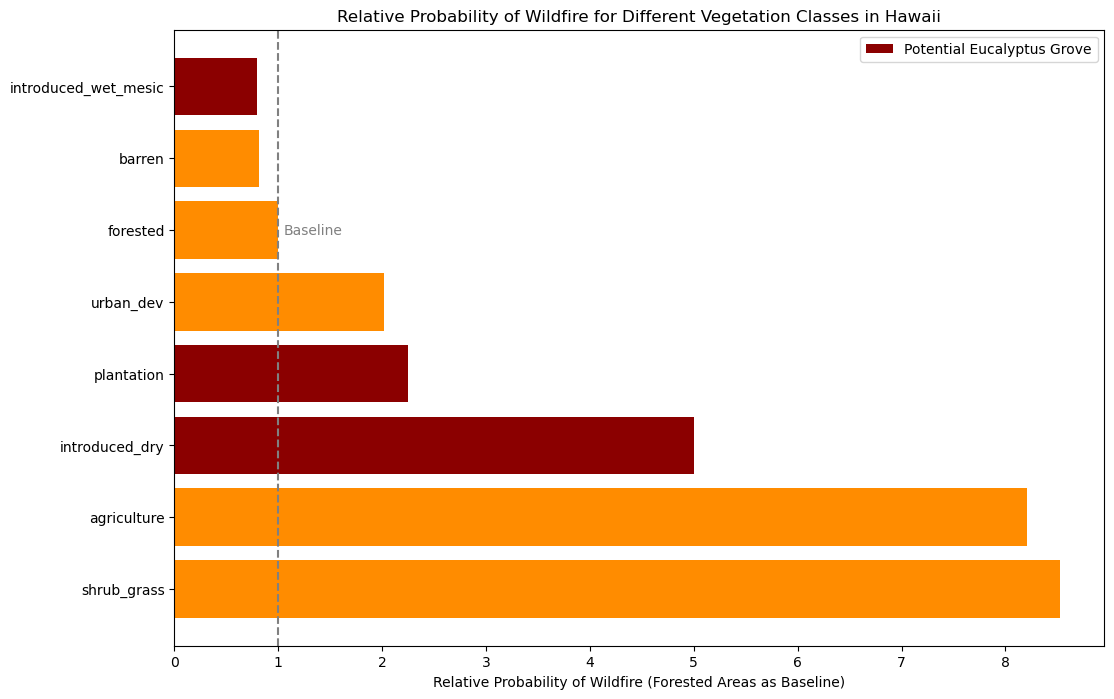

In [21]:
import matplotlib.pyplot as plt

# Given coefficients
coefficients = {
    'urban_dev': 2.019272,
    'agriculture': 8.209199,
    'barren': 0.814476,
    'shrub_grass': 8.526823,
    'introduced_dry': 5.005940,
    'introduced_wet_mesic': 0.791809,
    'plantation': 2.244695,
    'forested': 1.0
}

# Sort the coefficients by value
sorted_coefficients = dict(sorted(coefficients.items(), key=lambda item: item[1]))

# Extract sorted keys and values
labels = list(sorted_coefficients.keys())
values = list(sorted_coefficients.values())

# Define colors for bars
highlighted = ['introduced_dry', 'introduced_wet_mesic', 'plantation']
colors = ['darkred' if label in highlighted else 'darkorange' for label in labels]

# Create a bar plot
plt.figure(figsize=(12, 8))
bars = plt.barh(labels, values, color=colors)

# Add a vertical dashed line at x=1
plt.axvline(x=1, color='gray', linestyle='--')

# Add a label for the vertical line
plt.text(1.05, len(coefficients)-6, 'Baseline', color='gray', va='center')

# Add a legend for highlighted bars
plt.legend([bars[labels.index(label)] for label in highlighted], ['Potential Eucalyptus Grove'], loc='upper right')

# Set labels and title
plt.xlabel('Relative Probability of Wildfire (Forested Areas as Baseline)')
plt.title('Relative Probability of Wildfire for Different Vegetation Classes in Hawaii')

# Invert y-axis to display the highest value on top
plt.gca().invert_yaxis()

# Show plot
plt.show()


In [29]:
fire_sum = gdf_final.groupby('geometry')['fire'].sum().reset_index()

In [31]:
fire_total = gdf_final.groupby('geometry')['fire'].count().reset_index()

In [48]:
fire_sum['percent'] = fire_sum['fire'] / fire_total['fire'] * 1000

In [58]:
plantation = gdf_final.groupby('geometry')['plantation'].mean().reset_index()
introduced_dry = gdf_final.groupby('geometry')['introduced_dry'].mean().reset_index()
introduced_wet_mesic = gdf_final.groupby('geometry')['introduced_wet_mesic'].mean().reset_index()

In [66]:
type(fire_sum)

pandas.core.frame.DataFrame

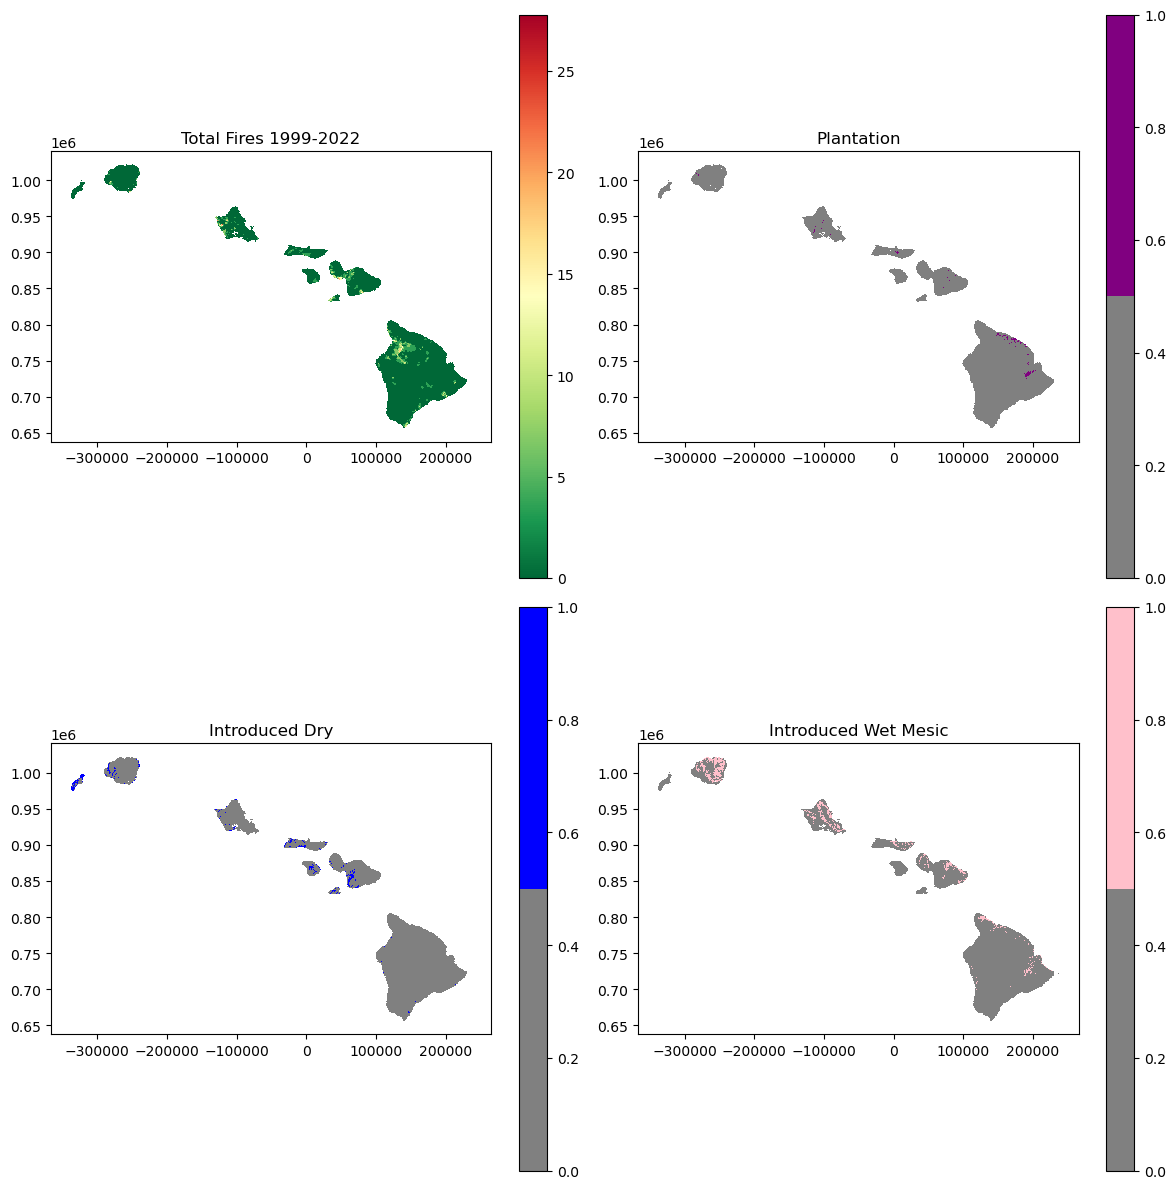

In [69]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from shapely.geometry import shape

# Function to convert a DataFrame with a geometry column to GeoDataFrame
def convert_to_geodataframe(df, geometry_col='geometry', crs='EPSG:4326'):
    # Ensure the geometry column is a geometry type
    df[geometry_col] = df[geometry_col].apply(lambda x: shape(eval(x)) if isinstance(x, str) else x)
    gdf = gpd.GeoDataFrame(df, geometry=geometry_col)
    gdf.set_crs(crs, inplace=True)
    return gdf

# Replace these with your actual DataFrames
# df_fire_sum, df_plantation, df_introduced_dry, df_introduced_wet_mesic

# Convert DataFrames to GeoDataFrames
fire_sum = convert_to_geodataframe(fire_sum)
plantation = convert_to_geodataframe(plantation)
introduced_dry = convert_to_geodataframe(introduced_dry)
introduced_wet_mesic = convert_to_geodataframe(introduced_wet_mesic)

# Define color maps
cmap_fire_sum = plt.get_cmap('RdYlGn_r')  # Reversed Red to Green colormap
cmap_plantation = mcolors.ListedColormap(['gray', 'purple'])
cmap_introduced_dry = mcolors.ListedColormap(['gray', 'blue'])
cmap_introduced_wet_mesic = mcolors.ListedColormap(['gray', 'pink'])

# Normalize values for fire_sum
norm_fire_sum = mcolors.Normalize(vmin=fire_sum['percent'].min(), vmax=fire_sum['percent'].max())

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Plot 1: Fire sum percentage with green to red color map
fire_sum.plot(column='percent', ax=axs[0, 0], cmap=cmap_fire_sum, norm=norm_fire_sum, legend=True)
axs[0, 0].set_title('Total Fires 1999-2022')

# Plot 2: Plantation with purple and gray
plantation.plot(column='plantation', ax=axs[0, 1], cmap=cmap_plantation, legend=True)
axs[0, 1].set_title('Plantation')

# Plot 3: Introduced Dry with blue and gray
introduced_dry.plot(column='introduced_dry', ax=axs[1, 0], cmap=cmap_introduced_dry, legend=True)
axs[1, 0].set_title('Introduced Dry')

# Plot 4: Introduced Wet Mesic with pink and gray
introduced_wet_mesic.plot(column='introduced_wet_mesic', ax=axs[1, 1], cmap=cmap_introduced_wet_mesic, legend=True)
axs[1, 1].set_title('Introduced Wet Mesic')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

Sources:

https://pacificfireexchange.org/resource/fire-data/

https://www.landfire.gov/data/FullExtentDownloads?field_version_target_id=All&field_theme_target_id=5&field_region_id_target_id=2

https://www.hawaiitourismauthority.org/research/historical-visitor-statistics/